In [122]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance

In [123]:
df_full = pd.read_csv("HRDataset_with_review_and_ancienete.csv")

df_full["DateofHire"] = pd.to_datetime(df_full["DateofHire"], errors="coerce")
df_full["DateofTermination"] = pd.to_datetime(df_full["DateofTermination"], errors="coerce")

df_full["ancienete"] = (
    df_full["DateofTermination"].fillna(pd.Timestamp.today())
    - df_full["DateofHire"]
).dt.days

df = df_full.copy()

employee_names = df_full[["EmpID", "Employee_Name"]].copy()

In [124]:

cols_to_drop = [
    "Employee_Name",
    "GenderID",
    "Sex",
    "MaritalDesc",
    "CitizenDesc",
    "HispanicLatino",
    "RaceDesc",
    "MaritalStatusID",
    "MarriedID",
    "PositionID",
    "Zip",
    "DateofTermination",
    "TermReason",
    "EmploymentStatus",
    "Internal_Transfer_Request",
    "EmpStatusID",
    "Feedback_RH",
    "DateofHire",
    "LastPerformanceReview_Date",
    "TimeSinceLastReview_days"
]

cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop_existing)
df = df.drop(columns=["DaysLateLast30"], errors="ignore")

In [125]:
target_col = "Termd"

if target_col not in df.columns:
    raise ValueError(f"La colonne cible '{target_col}' est introuvable.")

X = df.drop(columns=[target_col, "EmpID"], errors="ignore")
y = df[target_col].astype(int)

In [126]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Variables catégorielles :", categorical_features)
print("Variables numériques :", numeric_features)

Variables catégorielles : ['Position', 'State', 'DOB', 'Department', 'ManagerName', 'RecruitmentSource', 'PerformanceScore']
Variables numériques : ['DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'ManagerID', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'Absences', 'ancienete']


C:\Users\dridr\AppData\Local\Temp\ipykernel_31380\1031476952.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [127]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [128]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",   # utile si départs vs non-départs déséquilibrés
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [130]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [131]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("\n===== ÉVALUATION =====")
print("ROC AUC :", roc_auc_score(y_test, y_proba))
print("\nClassification report :")
print(classification_report(y_test, y_pred))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred))


===== ÉVALUATION =====
ROC AUC : 0.9993266748961958

Classification report :
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       133
           1       1.00      0.91      0.95        67

    accuracy                           0.97       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.97      0.97      0.97       200

Confusion matrix :
[[133   0]
 [  6  61]]


In [132]:
perm = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\n===== TOP VARIABLES EXPLICATIVES DES DÉPARTS =====")
print(feature_importance.head(15))


===== TOP VARIABLES EXPLICATIVES DES DÉPARTS =====
                   feature  importance_mean  importance_std
16               ancienete         0.310908        0.031593
10       RecruitmentSource         0.003243        0.002356
9                ManagerID         0.000449        0.000719
15                Absences         0.000303        0.000280
11        PerformanceScore         0.000090        0.000140
12        EngagementSurvey         0.000056        0.000056
13         EmpSatisfaction         0.000034        0.000072
1              PerfScoreID        -0.000022        0.000045
2   FromDiversityJobFairID        -0.000022        0.000045
3                   Salary        -0.000034        0.000219
0                   DeptID        -0.000045        0.000214
6                      DOB        -0.000056        0.000168
8              ManagerName        -0.000101        0.000500
14    SpecialProjectsCount        -0.000247        0.000180
5                    State        -0.000281     

In [133]:
active_employees = df_full[df_full["Termd"] == 0].copy()

# features used by the model
active_employees_X = active_employees.drop(columns=cols_to_drop_existing, errors="ignore")
active_employees_X = active_employees_X.drop(columns=[target_col, "EmpID"], errors="ignore")

# score
active_employees["risk_of_leaving"] = pipeline.predict_proba(active_employees_X)[:, 1]

# merge names back explicitly
at_risk_employees = active_employees.merge(
    employee_names,
    on="EmpID",
    how="left",
    suffixes=("", "_lookup")
)

# keep the best available name column
if "Employee_Name_lookup" in at_risk_employees.columns:
    at_risk_employees["Employee_Name"] = at_risk_employees["Employee_Name_lookup"].fillna(
        at_risk_employees.get("Employee_Name")
    )
    at_risk_employees = at_risk_employees.drop(columns=["Employee_Name_lookup"], errors="ignore")

risk_columns_to_show = [
    col for col in [
        "Employee_Name", "Department", "Position", "ManagerName",
        "Salary", "EngagementSurvey", "EmpSatisfaction",
        "Absences", "DaysLateLast30", "ancienete"
    ] if col in at_risk_employees.columns
]

at_risk_employees = at_risk_employees[risk_columns_to_show + ["risk_of_leaving"]] \
    .sort_values("risk_of_leaving", ascending=False)

print("\n===== EMPLOYÉS ENCORE PRÉSENTS LES PLUS À RISQUE =====")
print(at_risk_employees.head(20))

feature_importance.to_csv("importance_variables_departs.csv", index=False)
at_risk_employees.to_csv("employes_a_risque_depart.csv", index=False)

print("\nFichiers sauvegardés :")
print("- importance_variables_departs.csv")
print("- employes_a_risque_depart.csv")


===== EMPLOYÉS ENCORE PRÉSENTS LES PLUS À RISQUE =====
            Employee_Name         Department                  Position  \
454        Lindsay, Carla  Production          Production Technician I   
556          Zamora, Sean  Production          Production Technician I   
68        Fidelia,  Libby  Production          Production Technician I   
399       Tredinnick, Ned  Production               Production Manager   
557        Trzeciak, Cayo  Production          Production Technician I   
12        Bernstein, Sean  Production          Production Technician I   
275      Villanueva, John  Production          Production Technician I   
298         Mangal, Susan  Production          Production Technician I   
235      Buccheri, Roxana  Production               Production Manager   
19     Bugali, Josephine   Production          Production Technician I   
291       Baczenski, Anna  Production          Production Technician I   
242      Guilianno, April  Production          Productio

In [134]:
print("Employee_Name in X:", "Employee_Name" in X.columns)
print("EmpID in X:", "EmpID" in X.columns)
print("TimeSinceLastReview_days in X:", "TimeSinceLastReview_days" in X.columns)
print("Top columns in at_risk_employees:", at_risk_employees.columns.tolist())

Employee_Name in X: False
EmpID in X: False
TimeSinceLastReview_days in X: False
Top columns in at_risk_employees: ['Employee_Name', 'Department', 'Position', 'ManagerName', 'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'Absences', 'DaysLateLast30', 'ancienete', 'risk_of_leaving']


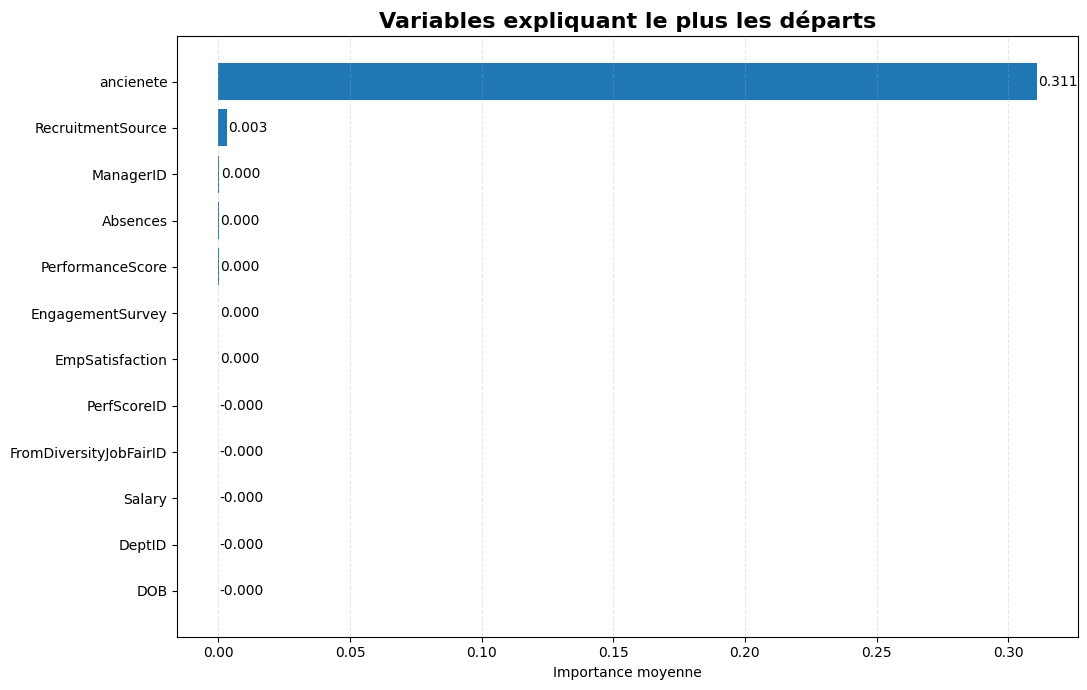

In [135]:
import matplotlib.pyplot as plt
import pandas as pd

top_features = feature_importance.head(12).copy()
top_features = top_features.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(11, 7))
bars = plt.barh(top_features["feature"], top_features["importance_mean"])

plt.title("Variables expliquant le plus les départs", fontsize=16, fontweight="bold")
plt.xlabel("Importance moyenne")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, val in zip(bars, top_features["importance_mean"]):
    plt.text(
        val + 0.0005,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

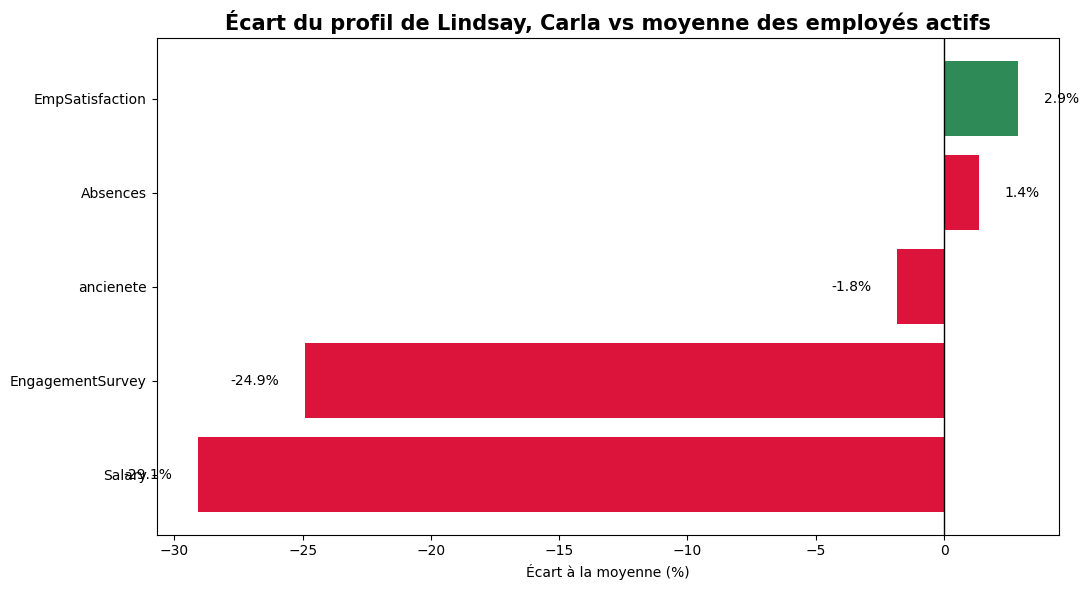

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pick the top at-risk employee
top_employee = at_risk_employees.iloc[0]
employee_name = top_employee["Employee_Name"]

# variables to compare
vars_to_compare = [
    "Absences",
    "EngagementSurvey",
    "EmpSatisfaction",
    "Salary",
    "ancienete"
]

available_vars = [v for v in vars_to_compare if v in at_risk_employees.columns]

# rebuild a reference set of active employees from df_full
active_reference = df_full[df_full["Termd"] == 0].copy()

comparison_df = pd.DataFrame({
    "Variable": available_vars,
    "Employe": [top_employee[v] for v in available_vars],
    "Moyenne": [active_reference[v].mean() for v in available_vars]
})

comparison_df["Ecart_pct"] = (
    (comparison_df["Employe"] - comparison_df["Moyenne"])
    / comparison_df["Moyenne"].replace(0, np.nan)
) * 100

comparison_df["Variable"] = comparison_df["Variable"].astype(str).str.strip()

# sort FIRST
comparison_df = comparison_df.sort_values("Ecart_pct").reset_index(drop=True)

# business logic for risk direction
risk_if_higher = ["Absences"]
risk_if_lower = ["Salary", "EmpSatisfaction", "EngagementSurvey", "ancienete"]

# build colors AFTER sorting
colors = []
for _, row in comparison_df.iterrows():
    var = row["Variable"]
    val = row["Ecart_pct"]

    if var in risk_if_higher:
        colors.append("crimson" if val > 0 else "seagreen")
    elif var in risk_if_lower:
        colors.append("crimson" if val < 0 else "seagreen")
    else:
        colors.append("gray")

plt.figure(figsize=(11, 6))
bars = plt.barh(comparison_df["Variable"], comparison_df["Ecart_pct"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title(
    f"Écart du profil de {employee_name} vs moyenne des employés actifs",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Écart à la moyenne (%)")
plt.ylabel("")

for bar, val in zip(bars, comparison_df["Ecart_pct"]):
    plt.text(
        val + (1 if val >= 0 else -1),
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}%",
        va="center",
        ha="left" if val >= 0 else "right"
    )

plt.tight_layout()
plt.show()

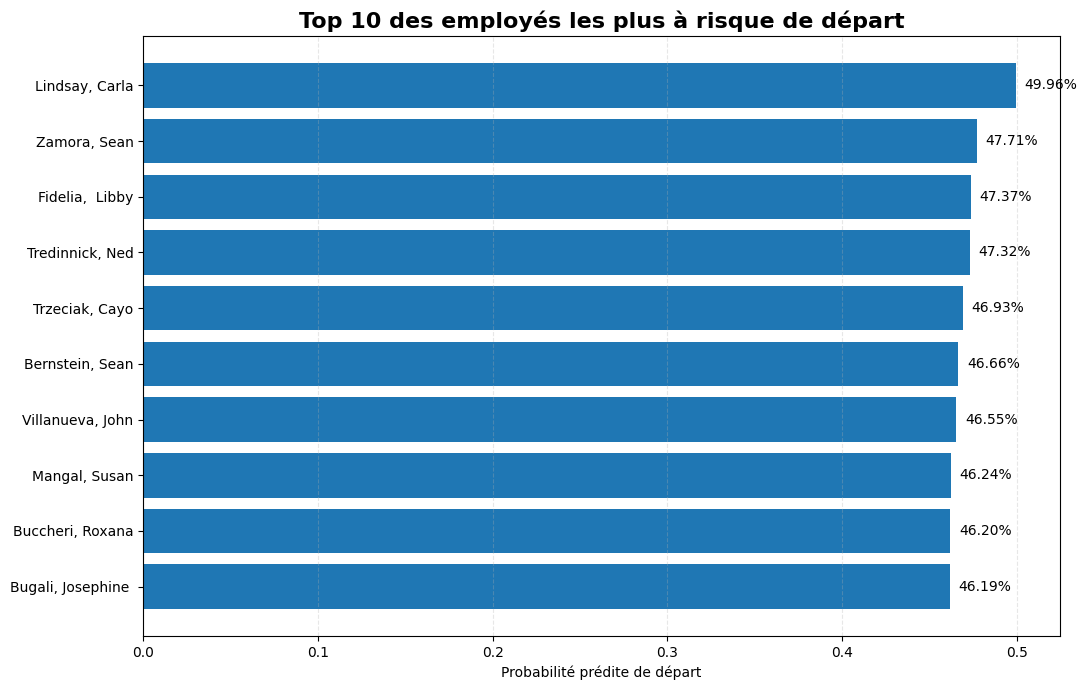

In [137]:
import matplotlib.pyplot as plt

top10 = at_risk_employees[["Employee_Name", "risk_of_leaving"]].head(10).copy()
top10 = top10.sort_values("risk_of_leaving", ascending=True)

plt.figure(figsize=(11, 7))
bars = plt.barh(top10["Employee_Name"], top10["risk_of_leaving"])

plt.title("Top 10 des employés les plus à risque de départ", fontsize=16, fontweight="bold")
plt.xlabel("Probabilité prédite de départ")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar, val in zip(bars, top10["risk_of_leaving"]):
    plt.text(
        val + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{val:.2%}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [138]:
display_cols = [
    col for col in [
        "Employee_Name", "Department", "Position",
        "Salary", "Absences", "EngagementSurvey",
        "EmpSatisfaction", "DaysLateLast30", "ancienete",
        "risk_of_leaving"
    ] if col in at_risk_employees.columns
]

top10_table = at_risk_employees[display_cols].head(10).copy()
print(top10_table)

          Employee_Name         Department                 Position  Salary  \
454      Lindsay, Carla  Production         Production Technician I   49847   
556        Zamora, Sean  Production         Production Technician I   47257   
68      Fidelia,  Libby  Production         Production Technician I   58530   
399     Tredinnick, Ned  Production              Production Manager   76143   
557      Trzeciak, Cayo  Production         Production Technician I   54550   
12      Bernstein, Sean  Production         Production Technician I   51044   
275    Villanueva, John  Production         Production Technician I   62022   
298       Mangal, Susan  Production         Production Technician I   63413   
235    Buccheri, Roxana  Production              Production Manager   63457   
19   Bugali, Josephine   Production         Production Technician I   64375   

     Absences  EngagementSurvey  EmpSatisfaction  DaysLateLast30  ancienete  \
454        10              3.08                4   